<a href="https://colab.research.google.com/github/SmitPatil2004/gearbox-fault-detection-uct/blob/main/notebooks/03_gearbox_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 8 — Week 3## Gearbox Fault Detection: Final Evaluation

### Step 1 — Load the feature table

In [1]:
import pandas as pd
import numpy  as np
import joblib

import matplotlib.pyplot as plt
import seaborn           as sns

from sklearn.ensemble        import RandomForestClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import make_pipeline
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.metrics         import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

sns.set_style('whitegrid')
pd.set_option('display.width', 120)

FEATURE_FILE = 'gearbox_features.csv'

data = pd.read_csv(FEATURE_FILE)

METADATA = [
    'condition',
    'load',
    'file',
]

FEATURES = [
    column
    for column in data.columns
    if column not in METADATA
]

n_recordings = data['file'].nunique()
load_levels  = sorted(data['load'].unique().tolist())

print('Dataset shape :', data.shape)
print('Feature count :', len(FEATURES))
print('Recordings    :', n_recordings)
print('Load levels   :', load_levels)
print()
print('Class balance')
print('-' * 30)
print(data['condition'].value_counts().to_string())

Dataset shape : (2009, 23)
Feature count : 20
Recordings    : 20
Load levels   : [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]

Class balance
------------------------------
condition
Healthy        1009
BrokenTooth    1000


### Step 2 — Hold out four complete files

In [2]:
TEST_FILES = [
    'h30hz20.txt',
    'h30hz60.txt',
    'b30hz20.txt',
    'b30hz60.txt',
]

is_test_file = data['file'].isin(TEST_FILES)

train = data[~is_test_file]
test  = data[ is_test_file]

X_train = train[FEATURES]
y_train = train['condition']

X_test = test[FEATURES]
y_test = test['condition']

n_train_files = train['file'].nunique()
n_test_files  = test['file'].nunique()

print('Training set')
print('-' * 40)
print(f'  Rows       : {len(train):>6,}')
print(f'  Recordings : {n_train_files:>6}')
print()
print('Test set')
print('-' * 40)
print(f'  Rows       : {len(test):>6,}')
print(f'  Recordings : {n_test_files:>6}')
print()
print(y_test.value_counts().to_string())

Training set
----------------------------------------
  Rows       :  1,593
  Recordings :     16

Test set
----------------------------------------
  Rows       :    416
  Recordings :      4

condition
BrokenTooth    209
Healthy        207


### Step 3 — Train and evaluate

In [3]:
model = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    n_jobs       = -1,
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy    = accuracy_score(y_test, predictions)
accuracy_pc = accuracy * 100

report = classification_report(
    y_test,
    predictions,
    digits = 4,
)

print('=' * 55)
print('  RESULTS — HELD-OUT RECORDINGS')
print('=' * 55)
print(f'  Accuracy : {accuracy:.4f}   ({accuracy_pc:.2f}%)')
print('=' * 55)
print()
print(report)

  RESULTS — HELD-OUT RECORDINGS
  Accuracy : 1.0000   (100.00%)

              precision    recall  f1-score   support

 BrokenTooth     1.0000    1.0000    1.0000       209
     Healthy     1.0000    1.0000    1.0000       207

    accuracy                         1.0000       416
   macro avg     1.0000    1.0000    1.0000       416
weighted avg     1.0000    1.0000    1.0000       416



### Step 4 — Confusion matrix

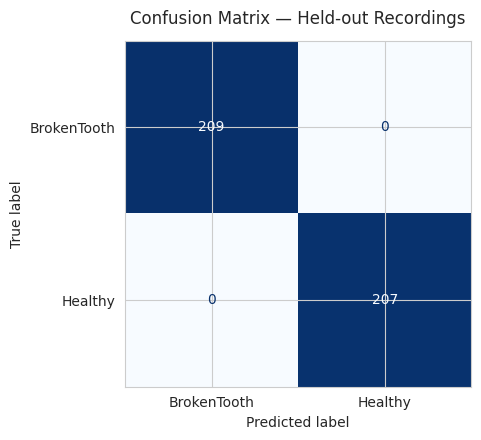


Breakdown
---------------------------------------------
  Broken  correctly identified :  209
  Broken  missed (false neg.)  :    0
  Healthy flagged (false pos.) :    0
  Healthy correctly identified :  207


In [4]:
LABELS = [
    'BrokenTooth',
    'Healthy',
]

cm = confusion_matrix(
    y_test,
    predictions,
    labels = LABELS,
)

fig, ax = plt.subplots(figsize=(5.5, 4.5))

display = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = LABELS,
)

display.plot(
    ax       = ax,
    cmap     = 'Blues',
    colorbar = False,
)

ax.set_title('Confusion Matrix — Held-out Recordings', pad=12)

plt.tight_layout()
plt.savefig('04_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

broken_correct  = cm[0][0]
broken_missed   = cm[0][1]
healthy_flagged = cm[1][0]
healthy_correct = cm[1][1]

print()
print('Breakdown')
print('-' * 45)
print(f'  Broken  correctly identified : {broken_correct:>4}')
print(f'  Broken  missed (false neg.)  : {broken_missed:>4}')
print(f'  Healthy flagged (false pos.) : {healthy_flagged:>4}')
print(f'  Healthy correctly identified : {healthy_correct:>4}')

### Step 5 — Feature importance

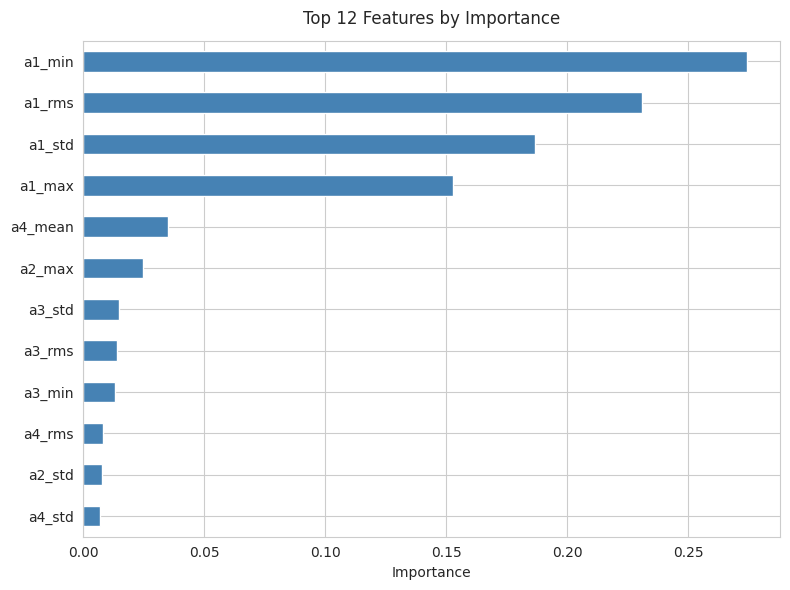


Top 10 features
------------------------------
a1_min     0.2742
a1_rms     0.2311
a1_std     0.1866
a1_max     0.1527
a4_mean    0.0350
a2_max     0.0244
a3_std     0.0145
a3_rms     0.0140
a3_min     0.0130
a4_rms     0.0079


In [5]:
importance = pd.Series(
    model.feature_importances_,
    index = FEATURES,
)

importance = importance.sort_values(ascending=False)

top_twelve = importance.head(12)
top_twelve = top_twelve.sort_values()

plt.figure(figsize=(8, 6))

top_twelve.plot(
    kind  = 'barh',
    color = 'steelblue',
)

plt.title('Top 12 Features by Importance', pad=12)
plt.xlabel('Importance')

plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print('Top 10 features')
print('-' * 30)
print(importance.head(10).round(4).to_string())

### Step 6 — Importance grouped by sensor and by statistic

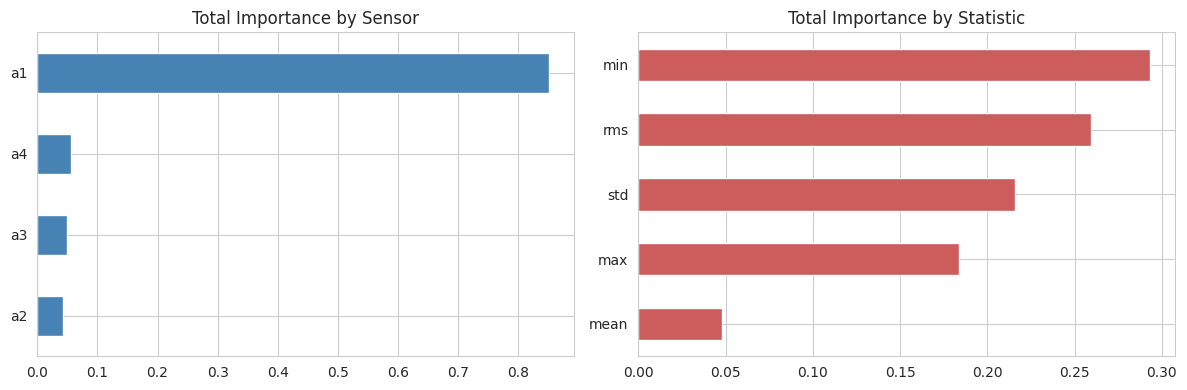


By sensor                By statistic
------------------------------------------
  a1      0.850         min     0.293
  a4      0.057         rms     0.259
  a3      0.050         std     0.216
  a2      0.043         max     0.184


In [6]:
sensor_names    = importance.index.str.split('_').str[0]
statistic_names = importance.index.str.split('_').str[1]

by_sensor = importance.groupby(sensor_names).sum()
by_sensor = by_sensor.sort_values(ascending=False)

by_statistic = importance.groupby(statistic_names).sum()
by_statistic = by_statistic.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

by_sensor.sort_values().plot(
    kind  = 'barh',
    ax    = axes[0],
    color = 'steelblue',
)

axes[0].set_title('Total Importance by Sensor')

by_statistic.sort_values().plot(
    kind  = 'barh',
    ax    = axes[1],
    color = 'indianred',
)

axes[1].set_title('Total Importance by Statistic')

plt.tight_layout()
plt.savefig('06_importance_grouped.png', dpi=120, bbox_inches='tight')
plt.show()

print()
print('By sensor                By statistic')
print('-' * 42)

paired = zip(by_sensor.items(), by_statistic.items())

for (sensor, sensor_value), (statistic, statistic_value) in paired:
    print(f'  {sensor:<6} {sensor_value:>6.3f}         {statistic:<6} {statistic_value:>6.3f}')

### Step 7 — Cross-load generalisation test

In [7]:
HELD_OUT_LOADS = [
    20,
    60,
]

is_held_out_load = data['load'].isin(HELD_OUT_LOADS)

train_loads = data[~is_held_out_load]
test_loads  = data[ is_held_out_load]

load_model = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    n_jobs       = -1,
)

load_model.fit(
    train_loads[FEATURES],
    train_loads['condition'],
)

load_predictions = load_model.predict(test_loads[FEATURES])

load_accuracy    = accuracy_score(test_loads['condition'], load_predictions)
load_accuracy_pc = load_accuracy * 100

load_report = classification_report(
    test_loads['condition'],
    load_predictions,
    digits = 4,
)

print('Trained on loads :', sorted(train_loads['load'].unique().tolist()))
print('Tested  on loads :', HELD_OUT_LOADS)
print()
print('=' * 55)
print('  RESULTS — UNSEEN OPERATING LOADS')
print('=' * 55)
print(f'  Accuracy : {load_accuracy:.4f}   ({load_accuracy_pc:.2f}%)')
print('=' * 55)
print()
print(load_report)

Trained on loads : [0, 10, 30, 40, 50, 70, 80, 90]
Tested  on loads : [20, 60]

  RESULTS — UNSEEN OPERATING LOADS
  Accuracy : 1.0000   (100.00%)

              precision    recall  f1-score   support

 BrokenTooth     1.0000    1.0000    1.0000       209
     Healthy     1.0000    1.0000    1.0000       207

    accuracy                         1.0000       416
   macro avg     1.0000    1.0000    1.0000       416
weighted avg     1.0000    1.0000    1.0000       416



### Step 8 — How much does one sensor carry?

In [8]:
a1_only = [
    column
    for column in FEATURES
    if column.startswith('a1')
]

without_a1 = [
    column
    for column in FEATURES
    if not column.startswith('a1')
]

subsets = {
    'All 20 features' : FEATURES,
    'Sensor a1 only'  : a1_only,
    'Without a1'      : without_a1,
}

results = []

for label, columns in subsets.items():

    subset_model = RandomForestClassifier(
        n_estimators = 200,
        random_state = 42,
        n_jobs       = -1,
    )

    subset_model.fit(
        train_loads[columns],
        train_loads['condition'],
    )

    subset_predictions = subset_model.predict(test_loads[columns])
    subset_accuracy    = accuracy_score(test_loads['condition'], subset_predictions)

    results.append({
        'Feature set' : label,
        'Features'    : len(columns),
        'Accuracy'    : round(subset_accuracy, 4),
    })

sensor_test = pd.DataFrame(results)
sensor_test

,Feature set,Features,Accuracy
0,All 20 features,20,1.0000
1,Sensor a1 only,5,0.9832
2,Without a1,15,0.9159


### Step 9 — Compare against simpler models

In [9]:
forest = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42,
    n_jobs       = -1,
)

tree = DecisionTreeClassifier(
    random_state = 42,
)

logistic = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000),
)

candidates = {
    'Random Forest'       : forest,
    'Decision Tree'       : tree,
    'Logistic Regression' : logistic,
}

results = []

for name, candidate in candidates.items():

    fold_scores = cross_val_score(
        candidate,
        data[FEATURES],
        data['condition'],
        cv     = GroupKFold(n_splits=5),
        groups = data['file'],
    )

    results.append({
        'Model'       : name,
        'CV Accuracy' : round(fold_scores.mean(), 4),
        'Std Dev'     : round(fold_scores.std(),  4),
    })

comparison = pd.DataFrame(results)
comparison = comparison.sort_values('CV Accuracy', ascending=False)
comparison

,Model,CV Accuracy,Std Dev
2,Logistic Regression,1.0000,0.0000
0,Random Forest,0.9975,0.0027
1,Decision Tree,0.9806,0.0069


### Step 10 — Save model and results

In [10]:
joblib.dump(model, 'gearbox_model.pkl')

summary_rows = [
    {
        'Evaluation' : 'Held-out recordings',
        'Accuracy'   : round(accuracy, 4),
    },
    {
        'Evaluation' : f'Unseen loads {HELD_OUT_LOADS}',
        'Accuracy'   : round(load_accuracy, 4),
    },
]

summary = pd.DataFrame(summary_rows)

summary.to_csv('final_summary_metrics.csv', index=False)
comparison.to_csv('model_comparison.csv', index=False)
sensor_test.to_csv('sensor_subset_results.csv', index=False)

importance.round(4).to_csv(
    'feature_importance.csv',
    header = ['importance'],
)

OUTPUTS = [
    'gearbox_model.pkl',
    'final_summary_metrics.csv',
    'model_comparison.csv',
    'sensor_subset_results.csv',
    'feature_importance.csv',
]

print('Files written')
print('-' * 40)

for filename in OUTPUTS:
    print('  ', filename)

print()
print(summary.to_string(index=False))

Files written
----------------------------------------
   gearbox_model.pkl
   final_summary_metrics.csv
   model_comparison.csv
   sensor_subset_results.csv
   feature_importance.csv

           Evaluation  Accuracy
  Held-out recordings       1.0
Unseen loads [20, 60]       1.0
